# 20 · Aggregate negative-news pressure as an SPY risk overlay

Notebook 19 showed why a firm-level brake is structurally unattractive: a
sparse one-day flag repeatedly exits and re-enters many names. This notebook
tests a materially different, low-turnover use of the same information:
aggregate FNSPID negative-news pressure controls exposure to one liquid market
instrument.

**Question.** Can an unusually negative market-wide news day improve the risk-
adjusted outcome of long SPY by moving 75% of capital to cash, either for one
session or until pressure normalises?

**Evidence status.** The complete design below was written before this
notebook calculated its returns. The 2020–2023 block has been opened by other
dissertation experiments, so the evidence is exploratory and cannot be called
pristine confirmation.

## Frozen design and gates

- **Spine:** FNSPID aggregates only. LSEG is not pooled.
- **Baseline:** continuously long SPY from adjusted open to next adjusted
  open; cash earns zero.
- **Signal:** headline-weighted daily negative share, standardised against the
  *prior* 252 sessions (minimum 126). The current day never enters its own
  normalisation baseline.
- **Entry:** risk-off when negative-pressure z-score is at least 1.5.
- **Exposure:** 0.25 while risk-off; otherwise 1.00. No leverage or shorting.
- **Two-arm family:** `one_day` restores full exposure next session;
  `hysteresis` stays risk-off until z-score is at most 0.5.
- **Timing:** existing conservative FNSPID mapping assigns date-only news to
  the first strictly later XNYS session; that mapped aggregate controls the
  return beginning at that session's open.
- **Primary cost:** 2 bps/side for SPY, including entry, changes and final
  liquidation. Sensitivity: 0/1/2/5/10 bps.
- **Split:** development through 2019-12-31; evaluation from 2020-01-01 to the
  last FNSPID signal session. No development return crosses the boundary.
- **Inference:** paired 20-session circular block bootstrap, 4,999
  replications, seed 20260805. BH q=0.05 across the two overlays separately
  for net-mean difference and downside-square difference.
- **Alpha gate:** positive paired net-mean difference that survives BH and an
  arm-level lower 95% net-mean bound above zero.
- **Useful risk-overlay gate:** evaluation net Sharpe at least 0.10 above
  baseline; maximum drawdown improves by at least 20% of the baseline loss;
  the paired net-mean lower bound exceeds a −1 bp/day non-inferiority margin;
  and downside squared return falls with BH significance.

The risk gate can support a risk-management result, not directional alpha.
Results are not tuned if either arm fails.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "final_experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    backtest_weight_panel,
    build_adjusted_open_returns,
    build_market_negative_pressure,
    build_market_risk_exposure,
    paired_block_bootstrap_difference,
    reprice_daily,
    summarize_weight_backtest,
)

SEED = 20260805
CONFIG = MomentumOverlayConfig(
    cost_bps_per_side=2.0,
    bootstrap_block_length=20,
    bootstrap_replications=4_999,
    random_seed=SEED,
)
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
ARMS = ("baseline", "one_day", "hysteresis")
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "20_fnspid_market_sentiment_risk_overlay"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
display(CONFIG)

MomentumOverlayConfig(lookback_sessions=252, skip_sessions=21, tail_fraction=0.1, min_universe=100, cost_bps_per_side=2.0, bootstrap_block_length=20, bootstrap_replications=4999, random_seed=20260805)

## Build the lagged market-pressure state

The displayed coverage and lag audit are aggregate. No headline text is read.

In [2]:
firm_day = pd.read_parquet(AGG_PATH)
firm_day["session_date"] = pd.to_datetime(firm_day["session_date"]).dt.normalize()
evaluation_end = firm_day["session_date"].max()
prices, missing_prices = load_adjusted_open_prices(DEFAULT_PRICE_ZIP, {"SPY"}, market_symbol="SPY")
spy_returns = build_adjusted_open_returns(prices, symbol="SPY", return_col="spy_return")
spy_returns = spy_returns.loc[spy_returns["session_date"].le(evaluation_end)].copy()
all_sessions = pd.DatetimeIndex(spy_returns["session_date"])

pressure = build_market_negative_pressure(
    firm_day,
    all_sessions,
    trailing_window=252,
    min_periods=126,
)
exposure_paths = {
    "one_day": build_market_risk_exposure(
        pressure,
        mode="one_day",
        entry_z=1.5,
        exit_z=0.5,
        risk_exposure=0.25,
    ),
    "hysteresis": build_market_risk_exposure(
        pressure,
        mode="hysteresis",
        entry_z=1.5,
        exit_z=0.5,
        risk_exposure=0.25,
    ),
}

lag_audit = pd.DataFrame(
    [
        {
            "sessions": len(pressure),
            "sessions_with_news": int(pressure["negative_pressure"].notna().sum()),
            "sessions_with_lagged_z": int(pressure["negative_pressure_z"].notna().sum()),
            "first_z_session": pressure.loc[pressure["negative_pressure_z"].notna(), "session_date"].min(),
            "missing_price_symbols": len(missing_prices),
            "evaluation_end": evaluation_end,
        }
    ]
)
display(lag_audit)
display(
    pressure[
        [
            "negative_pressure",
            "headline_count",
            "firms_with_news",
            "negative_pressure_z",
        ]
    ].describe()
)

,sessions,sessions_with_news,sessions_with_lagged_z,first_z_session,missing_price_symbols,evaluation_end
0,3262,3262,3136,2011-07-05,0,2023-12-18


,negative_pressure,headline_count,firms_with_news,negative_pressure_z
count,3262.000000,3262.000000,3262.000000,3136.000000
mean,0.163473,490.328326,219.358063,0.006458
std,0.047649,214.875811,66.182907,1.045930
min,0.021915,112.000000,67.000000,-2.742500
25%,0.131724,331.000000,165.000000,-0.700144
50%,0.158955,455.000000,216.000000,-0.095101
75%,0.190444,623.750000,271.000000,0.597965
max,0.550817,1566.000000,468.000000,6.890708


## Create split-safe SPY weight paths

Exposure states use only current mapped news and prior pressure history.
Backtests start from cash separately in each split and therefore pay the entry
cost rather than silently inheriting a development position.

In [3]:
dev_return_mask = spy_returns["session_date"].le(pd.Timestamp(FROZEN_DEV_END)) & spy_returns[
    "return_end_date"
].le(pd.Timestamp(FROZEN_DEV_END))
eval_return_mask = spy_returns["session_date"].ge(pd.Timestamp(FROZEN_EVAL_START))
split_returns = {
    "development": spy_returns.loc[dev_return_mask].copy(),
    "evaluation": spy_returns.loc[eval_return_mask].copy(),
}

weight_paths: dict[str, dict[str, pd.DataFrame]] = {}
activity_rows = []
for split, returns in split_returns.items():
    sessions = set(returns["session_date"])
    baseline = pressure.loc[pressure["session_date"].isin(sessions), ["session_date"]].assign(
        symbol="SPY",
        weight=1.0,
        risk_off=False,
    )
    weight_paths[split] = {"baseline": baseline}
    for arm in ("one_day", "hysteresis"):
        path = exposure_paths[arm].loc[
            exposure_paths[arm]["session_date"].isin(sessions),
            ["session_date", "exposure", "risk_off", "negative_pressure_z"],
        ].copy()
        path["symbol"] = "SPY"
        path = path.rename(columns={"exposure": "weight"})
        weight_paths[split][arm] = path
    for arm, path in weight_paths[split].items():
        activity_rows.append(
            {
                "split": split,
                "arm": arm,
                "sessions": len(path),
                "risk_off_sessions": int(path["risk_off"].sum()),
                "risk_off_share": float(path["risk_off"].mean()),
                "mean_exposure": float(path["weight"].mean()),
                "state_changes": int(path["weight"].diff().fillna(path["weight"]).ne(0).sum()),
            }
        )
activity = pd.DataFrame(activity_rows)
display(activity)

,split,arm,sessions,risk_off_sessions,risk_off_share,mean_exposure,state_changes
0,development,baseline,2263,0,0.000000,1.000000,1
1,development,one_day,2263,166,0.073354,0.944985,229
2,development,hysteresis,2263,254,0.112240,0.915820,195
3,evaluation,baseline,998,0,0.000000,1.000000,1
4,evaluation,one_day,998,81,0.081162,0.939128,123
5,evaluation,hysteresis,998,125,0.125251,0.906062,103


## Backtest the frozen family at 2 bps/side

In [4]:
daily_paths: dict[str, dict[str, pd.DataFrame]] = {}
summary_rows = []
for split, returns in split_returns.items():
    daily_paths[split] = {}
    return_frame = returns.rename(columns={"spy_return": "return"})
    for arm, weights in weight_paths[split].items():
        daily = backtest_weight_panel(
            weights,
            return_frame,
            cost_bps_per_side=CONFIG.cost_bps_per_side,
            return_col="return",
        )
        daily["downside_sq"] = np.minimum(daily["net_return"], 0.0) ** 2
        daily_paths[split][arm] = daily
        summary_rows.append({"split": split, "arm": arm, **summarize_weight_backtest(daily, config=CONFIG)})
results = pd.DataFrame(summary_rows)
display(
    results[
        [
            "split",
            "arm",
            "sharpe_net",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_turnover",
            "breakeven_bps_per_side",
            "bootstrap_net_ci_low",
            "bootstrap_net_ci_high",
        ]
    ]
)

,split,arm,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_turnover,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high
0,development,baseline,0.986724,2.192752,0.141165,-0.201499,0.000442,6256.271785,0.000240,0.000846
1,development,one_day,1.161083,2.567576,0.129225,-0.133727,0.038224,79.883780,0.000334,0.000847
2,development,hysteresis,1.074072,2.096126,0.124427,-0.145154,0.032589,83.365642,0.000273,0.000779
3,evaluation,baseline,0.567850,0.474961,0.213043,-0.320490,0.001002,2397.529805,-0.000372,0.001236
4,evaluation,one_day,0.576188,0.441751,0.192681,-0.286230,0.046844,49.024195,-0.000302,0.001125
5,evaluation,hysteresis,0.783125,0.635922,0.179220,-0.280052,0.039329,72.807352,-0.000099,0.001205


## Paired return and downside inference

Net mean and squared downside are separate two-arm families. A lower downside
difference is favourable; a positive net-mean difference is favourable.

In [5]:
inference_rows = []
for split in ("development", "evaluation"):
    for offset, arm in enumerate(("one_day", "hysteresis")):
        for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
            inference = paired_block_bootstrap_difference(
                daily_paths[split][arm],
                daily_paths[split]["baseline"],
                value_col=outcome,
                block_length=CONFIG.bootstrap_block_length,
                replications=CONFIG.bootstrap_replications,
                seed=SEED + offset + 10 * outcome_offset,
            )
            inference_rows.append(
                {
                    "split": split,
                    "arm": arm,
                    "outcome": outcome,
                    **inference,
                }
            )
inference_table = pd.DataFrame(inference_rows)
inference_table["bh_reject_q05"] = False
for (_split, _outcome), index in inference_table.groupby(["split", "outcome"]).groups.items():
    inference_table.loc[index, "bh_reject_q05"] = benjamini_hochberg(
        inference_table.loc[index, "p_two_sided"].tolist(),
        q=0.05,
    )
display(inference_table)

,split,arm,outcome,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,development,one_day,net_return,2263,0.000043,-0.000077,0.000180,0.4942,20,4999,20260805,False
1,development,one_day,downside_sq,2263,-0.000007,-0.000013,-0.000003,0.0096,20,4999,20260815,True
2,development,hysteresis,net_return,2263,-0.000022,-0.000166,0.000122,0.7610,20,4999,20260806,False
3,development,hysteresis,downside_sq,2263,-0.000009,-0.000015,-0.000004,0.0054,20,4999,20260816,True
4,evaluation,one_day,net_return,998,-0.000040,-0.000236,0.000180,0.6964,20,4999,20260805,False
5,evaluation,one_day,downside_sq,998,-0.000020,-0.000049,-0.000003,0.0812,20,4999,20260815,False
6,evaluation,hysteresis,net_return,998,0.000077,-0.000232,0.000474,0.6772,20,4999,20260806,False
7,evaluation,hysteresis,downside_sq,998,-0.000036,-0.000089,-0.000006,0.0786,20,4999,20260816,False


## Apply the predeclared gates

In [6]:
results["arm_net_mean_alpha_gate"] = results["bootstrap_net_ci_low"].gt(0)
eval_results = results.loc[results["split"].eq("evaluation")].set_index("arm")
eval_inference = inference_table.loc[inference_table["split"].eq("evaluation")].set_index(
    ["arm", "outcome"]
)
baseline_eval = eval_results.loc["baseline"]
gate_rows = []
for arm in ("one_day", "hysteresis"):
    arm_result = eval_results.loc[arm]
    return_test = eval_inference.loc[(arm, "net_return")]
    downside_test = eval_inference.loc[(arm, "downside_sq")]
    drawdown_improvement = float(arm_result["max_drawdown"] - baseline_eval["max_drawdown"])
    alpha_gate = bool(
        return_test["mean_difference"] > 0
        and return_test["bh_reject_q05"]
        and arm_result["bootstrap_net_ci_low"] > 0
    )
    useful_gate = bool(
        arm_result["sharpe_net"] >= baseline_eval["sharpe_net"] + 0.10
        and drawdown_improvement >= 0.20 * abs(baseline_eval["max_drawdown"])
        and return_test["ci_low"] >= -0.0001
        and downside_test["mean_difference"] < 0
        and downside_test["bh_reject_q05"]
    )
    gate_rows.append(
        {
            "arm": arm,
            "sharpe_improvement": float(arm_result["sharpe_net"] - baseline_eval["sharpe_net"]),
            "drawdown_improvement": drawdown_improvement,
            "net_mean_difference_bps_day": float(return_test["mean_difference"] * 10_000),
            "net_mean_ci_low_bps_day": float(return_test["ci_low"] * 10_000),
            "downside_sq_difference": float(downside_test["mean_difference"]),
            "downside_bh_reject": bool(downside_test["bh_reject_q05"]),
            "alpha_gate": alpha_gate,
            "useful_risk_overlay_gate": useful_gate,
        }
    )
gates = pd.DataFrame(gate_rows)
display(gates)

,arm,sharpe_improvement,drawdown_improvement,net_mean_difference_bps_day,net_mean_ci_low_bps_day,downside_sq_difference,downside_bh_reject,alpha_gate,useful_risk_overlay_gate
0,one_day,0.008338,0.034260,-0.395088,-2.36016,-0.000020,False,False,False
1,hysteresis,0.215275,0.040438,0.768855,-2.31827,-0.000036,False,False,False


## Cost and calendar-year stability

In [7]:
cost_rows = []
yearly_rows = []
for split, arms in daily_paths.items():
    for arm, daily in arms.items():
        for cost in COST_GRID:
            repriced = reprice_daily(daily, cost_bps_per_side=cost)
            cost_rows.append(
                {
                    "split": split,
                    "arm": arm,
                    "cost_bps_per_side": cost,
                    **summarize_weight_backtest(repriced, config=CONFIG),
                }
            )
        year_frame = daily.copy()
        year_frame["year"] = year_frame["session_date"].dt.year
        for year, group in year_frame.groupby("year"):
            net = group["net_return"].to_numpy(dtype=float)
            equity = np.cumprod(1.0 + net)
            vol = float(np.std(net, ddof=1))
            yearly_rows.append(
                {
                    "split": split,
                    "arm": arm,
                    "year": int(year),
                    "sessions": len(group),
                    "net_return": float(equity[-1] - 1.0),
                    "sharpe_net": float(math.sqrt(252) * np.mean(net) / vol) if vol > 0 else np.nan,
                }
            )
cost_curve = pd.DataFrame(cost_rows)
yearly = pd.DataFrame(yearly_rows)
display(cost_curve.loc[cost_curve["split"].eq("evaluation"), ["arm", "cost_bps_per_side", "sharpe_net", "total_return_net"]])
display(yearly.loc[yearly["split"].eq("evaluation")])

,arm,cost_bps_per_side,sharpe_net,total_return_net
15,baseline,0.0,0.568328,0.475552
16,baseline,1.0,0.568089,0.475257
17,baseline,2.0,0.567850,0.474961
18,baseline,5.0,0.567134,0.474074
19,baseline,10.0,0.565938,0.472597
20,one_day,0.0,0.600807,0.468999
21,one_day,1.0,0.588497,0.455312
22,one_day,2.0,0.576188,0.441751
23,one_day,5.0,0.539261,0.401816
24,one_day,10.0,0.477726,0.337682


,split,arm,year,sessions,net_return,sharpe_net
27,evaluation,baseline,2020,253,0.120822,0.531917
28,evaluation,baseline,2021,252,0.286001,2.112481
29,evaluation,baseline,2022,251,-0.179916,-0.704962
30,evaluation,baseline,2023,242,0.247798,1.759417
31,evaluation,one_day,2020,253,0.182040,0.789471
32,evaluation,one_day,2021,252,0.293870,2.293046
33,evaluation,one_day,2022,251,-0.239479,-1.068789
34,evaluation,one_day,2023,242,0.239527,1.769634
35,evaluation,hysteresis,2020,253,0.391292,1.605959
36,evaluation,hysteresis,2021,252,0.247135,2.013752


## Post-result attribution: timing versus lower average exposure

This diagnostic was added after seeing the frozen result and **cannot change
either gate**. A constant-exposure control uses the hysteresis arm's realised
mean evaluation exposure, so it is not an implementable ex-ante strategy. An
exact circular-shift placebo then moves the unchanged hysteresis exposure path
across returns, preserving its persistence and almost all turnover. Together
they ask whether the observed improvement is distinguishable from generic
de-risking or a lucky calendar alignment.

In [8]:
evaluation_return_frame = split_returns["evaluation"].rename(columns={"spy_return": "return"})
hysteresis_eval_weights = weight_paths["evaluation"]["hysteresis"].sort_values("session_date").copy()
mean_hysteresis_exposure = float(hysteresis_eval_weights["weight"].mean())
constant_weights = weight_paths["evaluation"]["baseline"].copy()
constant_weights["weight"] = mean_hysteresis_exposure
constant_daily = backtest_weight_panel(
    constant_weights,
    evaluation_return_frame,
    cost_bps_per_side=CONFIG.cost_bps_per_side,
    return_col="return",
)
constant_daily["downside_sq"] = np.minimum(constant_daily["net_return"], 0.0) ** 2
constant_summary = summarize_weight_backtest(constant_daily, config=CONFIG)
constant_inference = paired_block_bootstrap_difference(
    daily_paths["evaluation"]["hysteresis"],
    constant_daily,
    value_col="net_return",
    block_length=CONFIG.bootstrap_block_length,
    replications=CONFIG.bootstrap_replications,
    seed=SEED + 20,
)


def quick_path_summary(daily: pd.DataFrame) -> dict[str, float]:
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    vol = float(np.std(net, ddof=1))
    peak = np.maximum.accumulate(equity)
    return {
        "mean_net": float(np.mean(net)),
        "sharpe_net": float(math.sqrt(252) * np.mean(net) / vol) if vol > 0 else np.nan,
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(equity / peak - 1.0)),
    }


placebo_rows = []
exposure_values = hysteresis_eval_weights["weight"].to_numpy(dtype=float)
for shift in range(1, len(exposure_values)):
    shifted = hysteresis_eval_weights.copy()
    shifted["weight"] = np.roll(exposure_values, shift)
    shifted_daily = backtest_weight_panel(
        shifted,
        evaluation_return_frame,
        cost_bps_per_side=CONFIG.cost_bps_per_side,
        return_col="return",
    )
    placebo_rows.append({"circular_shift": shift, **quick_path_summary(shifted_daily)})
shift_placebo = pd.DataFrame(placebo_rows)
observed_hysteresis = quick_path_summary(daily_paths["evaluation"]["hysteresis"])
post_2020_baseline = quick_path_summary(
    daily_paths["evaluation"]["baseline"].loc[
        daily_paths["evaluation"]["baseline"]["session_date"].dt.year.ge(2021)
    ]
)
post_2020_hysteresis = quick_path_summary(
    daily_paths["evaluation"]["hysteresis"].loc[
        daily_paths["evaluation"]["hysteresis"]["session_date"].dt.year.ge(2021)
    ]
)
shift_p_sharpe = float(
    (1 + shift_placebo["sharpe_net"].ge(observed_hysteresis["sharpe_net"]).sum())
    / (len(shift_placebo) + 1)
)
shift_p_mean = float(
    (1 + shift_placebo["mean_net"].ge(observed_hysteresis["mean_net"]).sum())
    / (len(shift_placebo) + 1)
)
attribution = pd.DataFrame(
    [
        {
            "observed_hysteresis_sharpe": observed_hysteresis["sharpe_net"],
            "constant_exposure_sharpe": constant_summary["sharpe_net"],
            "observed_minus_constant_bps_day": constant_inference["mean_difference"] * 10_000,
            "observed_minus_constant_ci_low_bps_day": constant_inference["ci_low"] * 10_000,
            "observed_minus_constant_ci_high_bps_day": constant_inference["ci_high"] * 10_000,
            "observed_minus_constant_p": constant_inference["p_two_sided"],
            "circular_shift_upper_p_sharpe": shift_p_sharpe,
            "circular_shift_upper_p_mean": shift_p_mean,
            "n_nonzero_circular_shifts": len(shift_placebo),
            "post_2020_baseline_sharpe": post_2020_baseline["sharpe_net"],
            "post_2020_hysteresis_sharpe": post_2020_hysteresis["sharpe_net"],
            "post_2020_baseline_total_return": post_2020_baseline["total_return_net"],
            "post_2020_hysteresis_total_return": post_2020_hysteresis["total_return_net"],
        }
    ]
)
display(attribution)

,observed_hysteresis_sharpe,constant_exposure_sharpe,observed_minus_constant_bps_day,observed_minus_constant_ci_low_bps_day,observed_minus_constant_ci_high_bps_day,observed_minus_constant_p,circular_shift_upper_p_sharpe,circular_shift_upper_p_mean,n_nonzero_circular_shifts,post_2020_baseline_sharpe,post_2020_hysteresis_sharpe,post_2020_baseline_total_return,post_2020_hysteresis_total_return
0,0.783125,0.56785,1.219819,-1.573144,4.840917,0.4416,0.051102,0.091182,997,0.616953,0.417594,0.315963,0.175829


findfont: Failed to find font weight medium, now using 400.


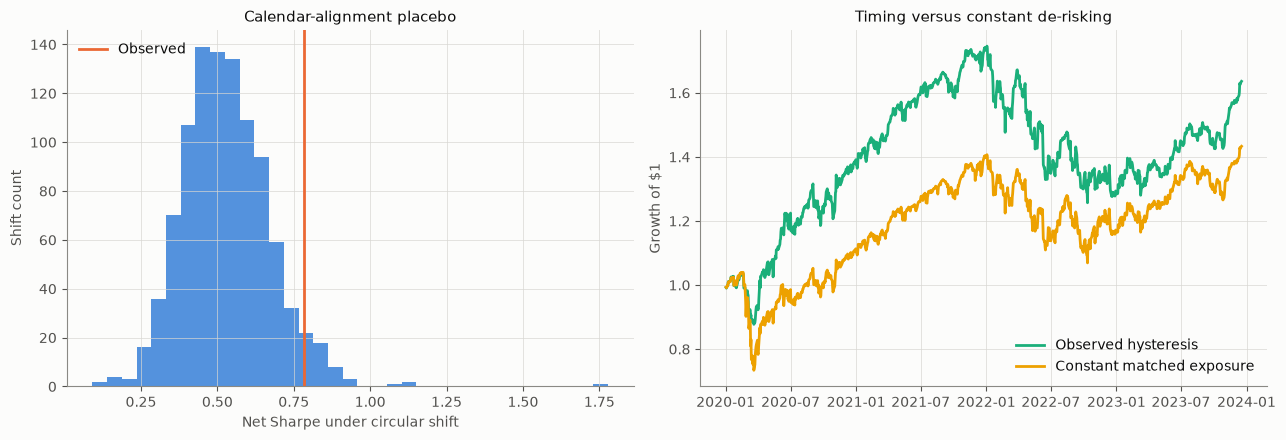

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(shift_placebo["sharpe_net"], bins=35, color=CATEGORICAL[0], alpha=0.8)
axes[0].axvline(observed_hysteresis["sharpe_net"], color=CATEGORICAL[1], linewidth=2, label="Observed")
axes[0].set_xlabel("Net Sharpe under circular shift")
axes[0].set_ylabel("Shift count")
axes[0].set_title("Calendar-alignment placebo")
axes[0].legend(loc="upper left")

for name, daily, colour in (
    ("Observed hysteresis", daily_paths["evaluation"]["hysteresis"], CATEGORICAL[2]),
    ("Constant matched exposure", constant_daily, CATEGORICAL[3]),
):
    equity = (1.0 + daily["net_return"]).cumprod()
    axes[1].plot(daily["session_date"], equity, label=name, color=colour)
axes[1].set_ylabel("Growth of $1")
axes[1].set_title("Timing versus constant de-risking")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "post_result_timing_attribution.png", dpi=170, bbox_inches="tight")
plt.show()

## Figures

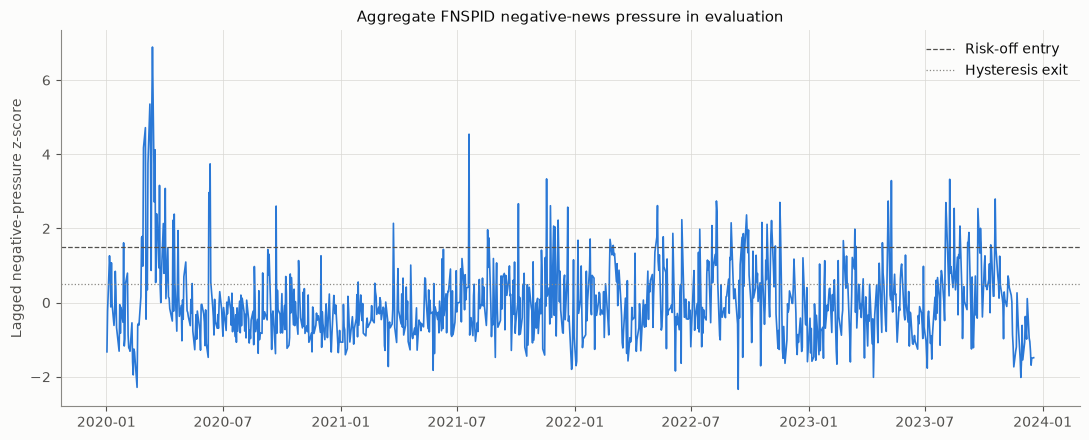

In [10]:
labels = {"baseline": "Long SPY", "one_day": "One-day risk-off", "hysteresis": "Hysteresis risk-off"}
colours = dict(zip(ARMS, CATEGORICAL[:3], strict=True))

fig, ax = plt.subplots(figsize=(11, 4.5))
eval_pressure = pressure.loc[pressure["session_date"].ge(pd.Timestamp(FROZEN_EVAL_START))]
ax.plot(eval_pressure["session_date"], eval_pressure["negative_pressure_z"], color=CATEGORICAL[0], linewidth=1.2)
ax.axhline(1.5, color=INK["reference"], linestyle="--", linewidth=0.9, label="Risk-off entry")
ax.axhline(0.5, color=INK["muted"], linestyle=":", linewidth=0.9, label="Hysteresis exit")
ax.set_ylabel("Lagged negative-pressure z-score")
ax.set_title("Aggregate FNSPID negative-news pressure in evaluation")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_negative_pressure.png", dpi=170, bbox_inches="tight")
plt.show()

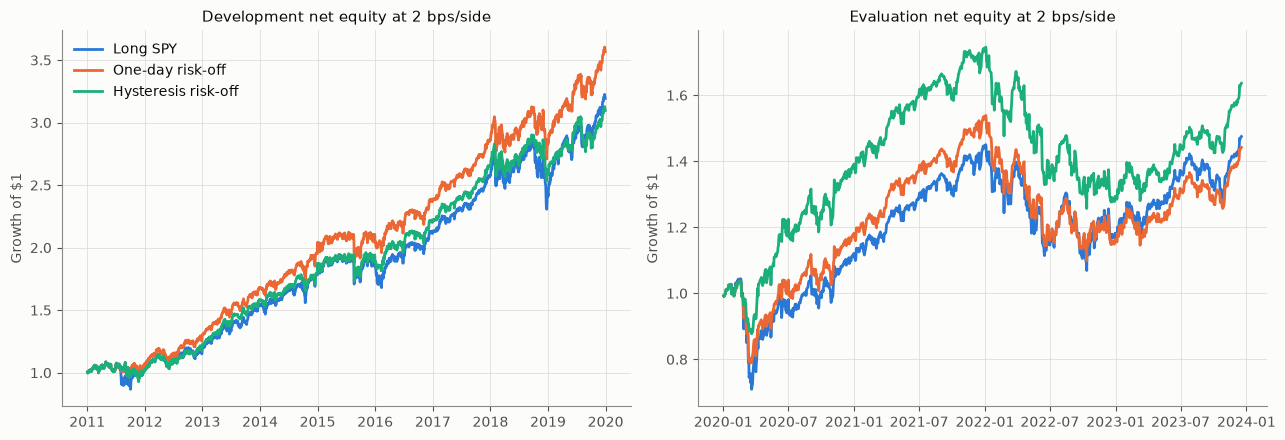

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, split in zip(axes, ("development", "evaluation"), strict=True):
    for arm in ARMS:
        daily = daily_paths[split][arm]
        equity = (1.0 + daily["net_return"]).cumprod()
        axis.plot(daily["session_date"], equity, label=labels[arm], color=colours[arm])
    axis.set_title(f"{split.capitalize()} net equity at 2 bps/side")
    axis.set_ylabel("Growth of $1")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "net_equity.png", dpi=170, bbox_inches="tight")
plt.show()

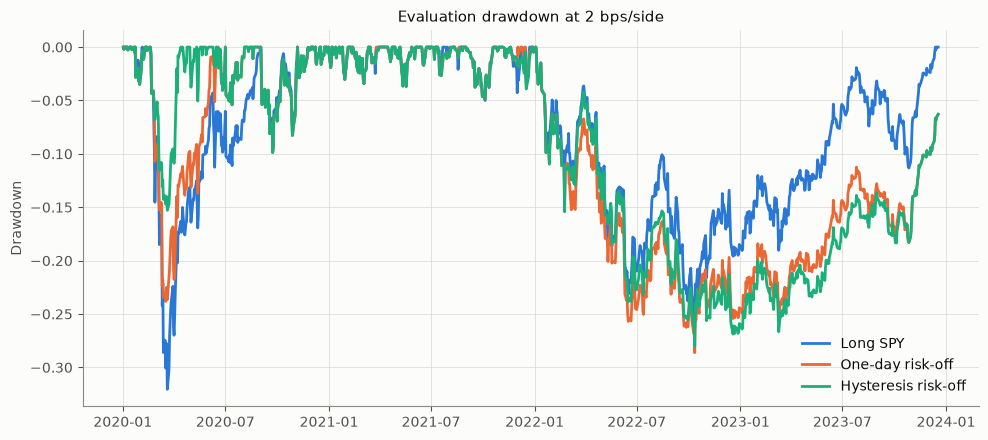

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for arm in ARMS:
    daily = daily_paths["evaluation"][arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    ax.plot(daily["session_date"], drawdown, label=labels[arm], color=colours[arm])
ax.set_ylabel("Drawdown")
ax.set_title("Evaluation drawdown at 2 bps/side")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

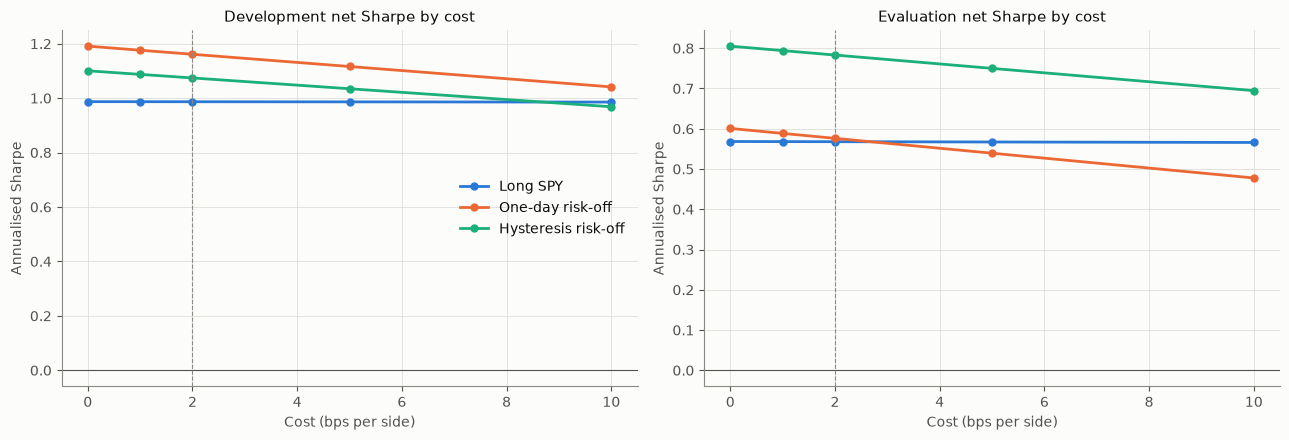

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, split in zip(axes, ("development", "evaluation"), strict=True):
    subset = cost_curve.loc[cost_curve["split"].eq(split)]
    for arm in ARMS:
        line = subset.loc[subset["arm"].eq(arm)]
        axis.plot(
            line["cost_bps_per_side"],
            line["sharpe_net"],
            marker="o",
            label=labels[arm],
            color=colours[arm],
        )
    axis.axhline(0.0, color=INK["reference"], linewidth=0.8)
    axis.axvline(CONFIG.cost_bps_per_side, color=INK["muted"], linewidth=0.8, linestyle="--")
    axis.set_title(f"{split.capitalize()} net Sharpe by cost")
    axis.set_xlabel("Cost (bps per side)")
    axis.set_ylabel("Annualised Sharpe")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

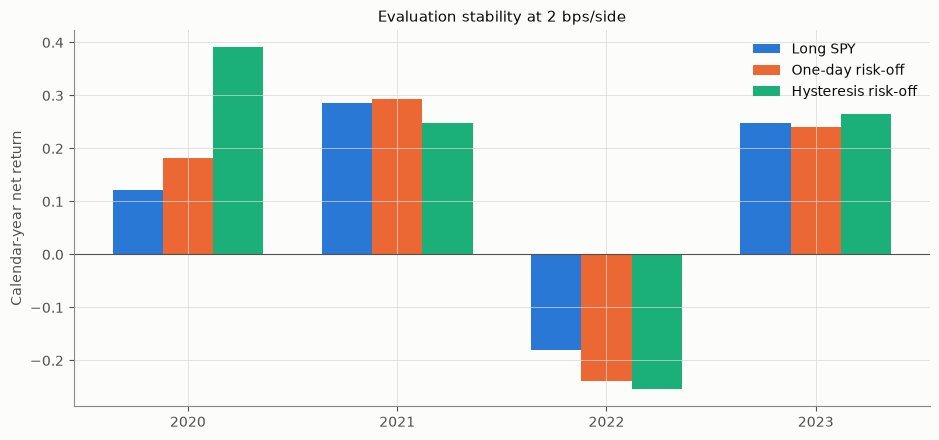

In [14]:
eval_yearly = yearly.loc[yearly["split"].eq("evaluation")]
years = sorted(eval_yearly["year"].unique())
x = np.arange(len(years))
width = 0.24
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for i, arm in enumerate(ARMS):
    values = eval_yearly.set_index(["arm", "year"]).loc[arm].reindex(years)["net_return"]
    ax.bar(x + (i - 1) * width, values, width, label=labels[arm], color=colours[arm])
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_xticks(x, years)
ax.set_ylabel("Calendar-year net return")
ax.set_title("Evaluation stability at 2 bps/side")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_yearly_return.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [15]:
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference_table.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
activity.to_csv(OUTPUT_DIR / "activity.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
yearly.to_csv(OUTPUT_DIR / "yearly_results.csv", index=False)
pressure.to_parquet(OUTPUT_DIR / "daily_aggregate_pressure.parquet", index=False)
attribution.to_csv(OUTPUT_DIR / "post_result_attribution.csv", index=False)
shift_placebo.to_csv(OUTPUT_DIR / "circular_shift_placebo.csv", index=False)
for split, arms in daily_paths.items():
    for arm, daily in arms.items():
        daily.to_parquet(OUTPUT_DIR / f"{split}_{arm}_daily.parquet", index=False)

alpha_passes = gates.loc[gates["alpha_gate"], "arm"].tolist()
useful_passes = gates.loc[gates["useful_risk_overlay_gate"], "arm"].tolist()
if alpha_passes:
    verdict = f"Alpha gate passed by: {', '.join(alpha_passes)}."
elif useful_passes:
    verdict = f"Risk-overlay gate passed by: {', '.join(useful_passes)}; this is risk management, not alpha."
else:
    verdict = "Neither market-sentiment overlay clears the alpha or useful-risk gate."

manifest = {
    "notebook": "20_fnspid_market_sentiment_risk_overlay",
    "built_for": "aggregate negative-news SPY exposure timing",
    "analysis_status": "exploratory_frozen_before_notebook20_return_execution_2026-08-05",
    "spine": "FNSPID_aggregate_only",
    "split": {
        "development_end": FROZEN_DEV_END,
        "evaluation_start": FROZEN_EVAL_START,
        "evaluation_end": str(evaluation_end.date()),
        "evaluation_previously_opened_elsewhere": True,
    },
    "design": {
        "signal": "headline-weighted negative share z-scored against prior 252 sessions; minimum 126",
        "entry_z": 1.5,
        "exit_z_hysteresis": 0.5,
        "risk_exposure": 0.25,
        "arms": ["one_day", "hysteresis"],
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "cost_grid": list(COST_GRID),
        "inference": "paired 20-session circular block bootstrap; 4999 replications; BH q=0.05 per two-arm outcome family",
        "noninferiority_margin_bps_day": -1.0,
        "seed": SEED,
    },
    "lag_audit": json.loads(lag_audit.to_json(orient="records", date_format="iso"))[0],
    "activity": json.loads(activity.to_json(orient="records")),
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(inference_table.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records")),
    "post_result_attribution": json.loads(attribution.to_json(orient="records"))[0],
    "alpha_gate_passes": alpha_passes,
    "useful_risk_overlay_passes": useful_passes,
    "verdict": verdict,
    "limitations": [
        "the 2020-2023 block has influenced prior dissertation work",
        "FNSPID date-only timing uses a conservative next-session convention",
        "cash return is fixed at zero rather than a historical risk-free rate",
        "SPY adjusted opens are split-adjusted but not dividend-adjusted",
        "aggregate pressure inherits changing news coverage and machine-label error",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

base = eval_results.loc["baseline"]
one = eval_results.loc["one_day"]
hyst = eval_results.loc["hysteresis"]
base_line = (
    f"- Long SPY: net Sharpe **{base['sharpe_net']:.3f}**, return **{base['total_return_net']:.2%}**, "
    f"maximum drawdown **{base['max_drawdown']:.2%}**."
)
one_line = (
    f"- One-day overlay: net Sharpe **{one['sharpe_net']:.3f}**, return **{one['total_return_net']:.2%}**, "
    f"maximum drawdown **{one['max_drawdown']:.2%}**, risk-off on "
    f"**{activity.set_index(['split', 'arm']).loc[('evaluation', 'one_day'), 'risk_off_share']:.1%}** of sessions."
)
hyst_line = (
    f"- Hysteresis overlay: net Sharpe **{hyst['sharpe_net']:.3f}**, return **{hyst['total_return_net']:.2%}**, "
    f"maximum drawdown **{hyst['max_drawdown']:.2%}**, risk-off on "
    f"**{activity.set_index(['split', 'arm']).loc[('evaluation', 'hysteresis'), 'risk_off_share']:.1%}** of sessions."
)
attribution_line = (
    f"- Post-result attribution: matched constant exposure Sharpe **{constant_summary['sharpe_net']:.3f}**; "
    f"circular-shift upper-tail p-values are **{shift_p_sharpe:.3f}** for Sharpe and "
    f"**{shift_p_mean:.3f}** for mean return. Over 2021–2023 alone, baseline/hysteresis "
    f"Sharpes are **{post_2020_baseline['sharpe_net']:.3f}/{post_2020_hysteresis['sharpe_net']:.3f}**. "
    "These diagnostics do not alter the gate."
)
display(
    Markdown(
        f"""### Decision

**{verdict}**

{base_line}
{one_line}
{hyst_line}
{attribution_line}

Lower exposure alone is not a successful result. The declared gate requires a
material Sharpe/drawdown improvement, return non-inferiority, and corrected
downside-risk evidence.
"""
    )
)

### Decision

**Neither market-sentiment overlay clears the alpha or useful-risk gate.**

- Long SPY: net Sharpe **0.568**, return **47.50%**, maximum drawdown **-32.05%**.
- One-day overlay: net Sharpe **0.576**, return **44.18%**, maximum drawdown **-28.62%**, risk-off on **8.1%** of sessions.
- Hysteresis overlay: net Sharpe **0.783**, return **63.59%**, maximum drawdown **-28.01%**, risk-off on **12.5%** of sessions.
- Post-result attribution: matched constant exposure Sharpe **0.568**; circular-shift upper-tail p-values are **0.051** for Sharpe and **0.091** for mean return. Over 2021–2023 alone, baseline/hysteresis Sharpes are **0.617/0.418**. These diagnostics do not alter the gate.

Lower exposure alone is not a successful result. The declared gate requires a
material Sharpe/drawdown improvement, return non-inferiority, and corrected
downside-risk evidence.
